# 03 — Portfolio Construction

Notebook 02 found three regimes, each with a different best asset. Here we turn that into **weights**: for each regime, we estimate the assets' mean returns and covariance, then optimize a long-only portfolio.

Three methods are compared:

| Method | Uses expected returns? | Idea |
|---|---|---|
| `min_variance` | No | Lowest risk |
| `risk_parity` | No | Each asset contributes equal risk |
| `max_sharpe` | Yes | Best return per unit of risk |

No asset can exceed **80%**, so the optimizer can't go all-in.

**Timing rule:** weights chosen at the close of day *t* earn day *t+1*'s return.

⚠️ Everything here is **in-sample**: regimes and weights are estimated on the full history. Results will look better than reality. Step 4 does the honest out-of-sample test.

All logic lives in `src/portfolio.py`.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd

from src.data import download_prices, compute_returns
from src.regimes import build_features, load_model, predict_regimes
from src.portfolio import (
    regime_weights, daily_weights, static_weights, portfolio_returns, performance, METHODS,
)

## 1. Load data and the regimes from Step 2

In [2]:
prices = download_prices()
returns = compute_returns(prices)
features = build_features(returns)

model, scaler, _ = load_model()          # model/hmm.pkl saved in notebook 02
regimes, remap = predict_regimes(model, scaler, features)
regimes.value_counts().sort_index()

regime
0    2065
1    2328
2     993
Name: count, dtype: int64

## 2. Weights per regime, for each method

In [3]:
weight_tables = {m: regime_weights(returns, regimes, method=m) for m in METHODS}
for m, table in weight_tables.items():
    print(m)
    display(table.round(2))

min_variance


,SPY,TLT,GLD
regime,,,
0,0.46,0.42,0.12
1,0.42,0.47,0.11
2,0.25,0.51,0.24


max_sharpe


,SPY,TLT,GLD
regime,,,
0,0.70,0.00,0.30
1,0.41,0.49,0.10
2,0.34,0.02,0.64


risk_parity


,SPY,TLT,GLD
regime,,,
0,0.40,0.37,0.24
1,0.37,0.40,0.23
2,0.27,0.43,0.30


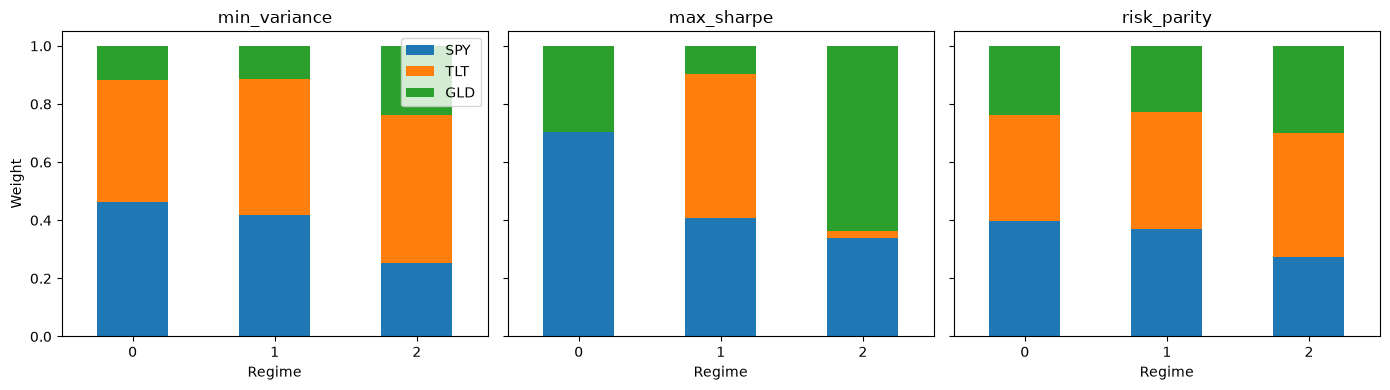

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (m, table) in zip(axes, weight_tables.items()):
    table.plot(kind="bar", stacked=True, ax=ax, rot=0,
               color=["tab:blue", "tab:orange", "tab:green"], legend=(ax is axes[0]))
    ax.set_title(m)
    ax.set_xlabel("Regime")
axes[0].set_ylabel("Weight")
plt.tight_layout()
plt.show()

## 3. In-sample performance vs benchmarks
Benchmarks: **60/40** (60% SPY, 40% TLT) and **equal weight** (⅓ each). A cost of 5 basis points is charged each time the weights change.

In [5]:
idx = regimes.index
strategies = {
    "60/40": static_weights(idx),
    "Equal weight": static_weights(idx, {"SPY": 1/3, "TLT": 1/3, "GLD": 1/3}),
}
for m, table in weight_tables.items():
    strategies[f"Regime {m}"] = daily_weights(regimes, table)

port_rets = {name: portfolio_returns(returns, w, cost_bps=5) for name, w in strategies.items()}
results = pd.DataFrame({name: performance(r, name) for name, r in port_rets.items()}).T
results.round(3)

,ann_return,ann_vol,sharpe,max_drawdown,final_wealth
60/40,0.088,0.111,0.786,-0.299,6.006
Equal weight,0.095,0.099,0.962,-0.227,6.918
Regime min_variance,0.084,0.089,0.946,-0.266,5.659
Regime max_sharpe,0.123,0.114,1.073,-0.234,11.888
Regime risk_parity,0.090,0.092,0.983,-0.247,6.326


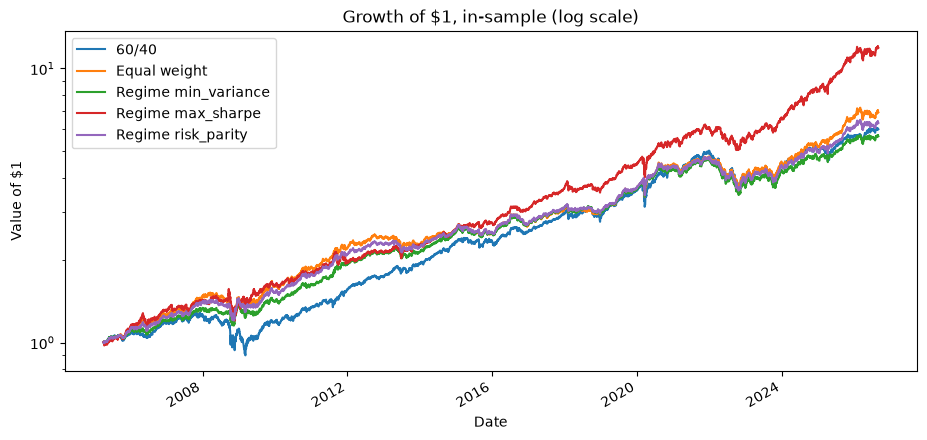

In [6]:
wealth = pd.DataFrame({name: (1 + r).cumprod() for name, r in port_rets.items()})
ax = wealth.plot(logy=True, figsize=(11, 5), title="Growth of $1, in-sample (log scale)")
ax.set_ylabel("Value of $1")
plt.show()

## 4. Key numbers (text summary)

In [7]:
for m, table in weight_tables.items():
    print(f"\nWeights ({m}):")
    print(table.round(2).to_string())
print("\nIn-sample performance (5 bps costs):")
print(results.round(3).to_string())


Weights (min_variance):
         SPY   TLT   GLD
regime                  
0       0.46  0.42  0.12
1       0.42  0.47  0.11
2       0.25  0.51  0.24

Weights (max_sharpe):
         SPY   TLT   GLD
regime                  
0       0.70  0.00  0.30
1       0.41  0.49  0.10
2       0.34  0.02  0.64

Weights (risk_parity):
         SPY   TLT   GLD
regime                  
0       0.40  0.37  0.24
1       0.37  0.40  0.23
2       0.27  0.43  0.30

In-sample performance (5 bps costs):
                     ann_return  ann_vol  sharpe  max_drawdown  final_wealth
60/40                     0.088    0.111   0.786        -0.299         6.006
Equal weight              0.095    0.099   0.962        -0.227         6.918
Regime min_variance       0.084    0.089   0.946        -0.266         5.659
Regime max_sharpe         0.123    0.114   1.073        -0.234        11.888
Regime risk_parity        0.090    0.092   0.983        -0.247         6.326


## Takeaways

| Strategy | Return/yr | Vol | Sharpe | Max drawdown | $1 became |
|---|---|---|---|---|---|
| 60/40 | 8.8% | 11.1% | 0.79 | −29.9% | $6.01 |
| Equal weight | 9.5% | 9.9% | 0.96 | −22.7% | $6.92 |
| Regime min variance | 8.4% | 8.9% | 0.95 | −26.6% | $5.66 |
| Regime risk parity | 9.0% | 9.2% | 0.98 | −24.7% | $6.33 |
| **Regime max Sharpe** | **12.3%** | 11.4% | **1.07** | −23.4% | **$11.89** |

**1. Max Sharpe is the only regime strategy that adds value.** Its weights follow the regimes: 70% SPY when calm without bond hedging, a balanced SPY/TLT mix when bonds hedge, 64% GLD in stress.

**2. Equal weight is the real benchmark.** Simply adding gold lifts Sharpe from 0.79 (60/40) to 0.96 with no model. The regime model's own contribution is 0.96 → 1.07.

**3. Min variance and risk parity barely change across regimes**, so they behave like static portfolios. Regimes differ mainly in returns, not risk.

*Caveat: in-sample. Regimes and expected returns are estimated on the full history, so these results are an upper bound. Step 4 tests the strategy out-of-sample.*